# Wobble Excitation Analysis

Is the Chandler/annual wobble declining because **excitation is weakening**
or because **dissipation is changing**?

Approach:
1. Compute equatorial excitation functions from AAM + OAM (χ₁, χ₂)
2. Compare excitation amplitude trends with observed wobble amplitude trends
3. Spectral coherence — is the forcing still coherent with the response?
4. Liouville equation inversion — predict polar motion from forcing, compare residual over time

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DATA_DIR = Path('../data')

## 1. Load observed polar motion

In [7]:
eop = pd.read_csv(
    DATA_DIR / 'EOP_14_C04_IAU2000A_one_file_1962-now.txt',
    sep=r'\s+',
    skiprows=14,
    names=['Year','Month','Day','MJD',
           'x','y','UT1_UTC','LOD',
           'dX','dY','x_Err','y_Err',
           'UT1_UTC_Err','LOD_Err','dX_Err','dY_Err']
)
eop['date'] = pd.to_datetime(eop[['Year','Month','Day']])
eop.set_index('date', inplace=True)

# Polar motion in arcseconds; convert to mas
eop['x_mas'] = eop['x'] * 1000
eop['y_mas'] = eop['y'] * 1000

# Remove linear trend (secular polar drift)
pm_idx = eop['x'].dropna().index
x_det = signal.detrend(eop.loc[pm_idx, 'x'].values) * 1000  # mas
y_det = signal.detrend(eop.loc[pm_idx, 'y'].values) * 1000  # mas

print(f"EOP range: {pm_idx[0].date()} to {pm_idx[-1].date()} ({len(pm_idx):,} days)")

EOP range: 1962-01-01 to 2026-01-05 (23,381 days)


## 2. Load equatorial AAM and OAM

ESMGFZ data provides Mass_X, Mass_Y, Motion_X, Motion_Y — the equatorial
angular momentum excitation functions. The total equatorial excitation is:

$$\chi_1 = \text{Mass\_X} + \text{Motion\_X}$$
$$\chi_2 = \text{Mass\_Y} + \text{Motion\_Y}$$

In [8]:
def load_angular_momentum(pattern, label):
    """Load AAM or OAM files, compute equatorial excitation, resample to daily."""
    files = sorted(DATA_DIR.glob(pattern))
    if not files:
        print(f'No {label} files found.')
        return None
    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=';')
        df['datetime'] = pd.to_datetime(
            df['Year'].astype(str) + '-' +
            df['Month'].astype(str).str.zfill(2) + '-' +
            df['Day'].astype(str).str.zfill(2) + ' ' +
            df['Time']
        )
        df.set_index('datetime', inplace=True)
        dfs.append(df)
    data = pd.concat(dfs).sort_index()
    # Equatorial excitation functions
    data['chi1'] = data['Mass_X'] + data['Motion_X']
    data['chi2'] = data['Mass_Y'] + data['Motion_Y']
    # Also keep mass and motion separate for decomposition
    daily = data[['Mass_X','Mass_Y','Motion_X','Motion_Y','chi1','chi2']].resample('D').mean()
    print(f"{label}: {daily.index[0].date()} to {daily.index[-1].date()} ({len(daily):,} days)")
    return daily

aam = load_angular_momentum('ESMGFZ_AAM_v1.0_03h_*.asc.csv', 'AAM')
oam = load_angular_momentum('ESMGFZ_OAM_v1.0_03h_*.asc.csv', 'OAM')

AAM: 1976-01-01 to 2026-02-06 (18,300 days)
OAM: 1976-01-01 to 2026-02-06 (18,300 days)


In [9]:
# Combined excitation: AAM + OAM
if oam is not None:
    common = aam.index.intersection(oam.index)
    combined = pd.DataFrame({
        'chi1_aam': aam.loc[common, 'chi1'],
        'chi2_aam': aam.loc[common, 'chi2'],
        'chi1_oam': oam.loc[common, 'chi1'],
        'chi2_oam': oam.loc[common, 'chi2'],
        'chi1_total': aam.loc[common, 'chi1'] + oam.loc[common, 'chi1'],
        'chi2_total': aam.loc[common, 'chi2'] + oam.loc[common, 'chi2'],
    })
else:
    common = aam.index
    combined = pd.DataFrame({
        'chi1_aam': aam['chi1'],
        'chi2_aam': aam['chi2'],
        'chi1_total': aam['chi1'],
        'chi2_total': aam['chi2'],
    })

# Complex excitation (stored separately, not in the DataFrame)
chi_aam_complex = combined['chi1_aam'] + 1j * combined['chi2_aam']
chi_total_complex = combined['chi1_total'] + 1j * combined['chi2_total']

print(f"Combined excitation range: {combined.index[0].date()} to {combined.index[-1].date()}")
combined.describe()

Combined excitation range: 1976-01-01 to 2026-02-06


,chi1_aam,chi2_aam,chi1_oam,chi2_oam,chi1_total,chi2_total
count,1.830000e+04,1.830000e+04,1.830000e+04,1.830000e+04,1.830000e+04,1.830000e+04
mean,8.631869e-09,-3.398421e-10,1.118440e-08,-1.038684e-08,1.981627e-08,-1.072668e-08
std,8.735508e-08,1.673798e-07,9.996753e-08,1.496359e-07,1.327929e-07,2.247785e-07
min,-3.220869e-07,-6.932561e-07,-3.918318e-07,-5.851310e-07,-4.635441e-07,-8.881311e-07
25%,-5.008715e-08,-1.103101e-07,-5.429697e-08,-1.094505e-07,-7.046600e-08,-1.609513e-07
50%,8.219439e-09,1.079279e-08,1.061320e-08,-8.856879e-09,1.732841e-08,-6.070742e-09
75%,6.637113e-08,1.190554e-07,7.882563e-08,9.059020e-08,1.084812e-07,1.435132e-07
max,3.570999e-07,4.800763e-07,3.734171e-07,5.598139e-07,5.602105e-07,8.343635e-07


## 3. Bandpass extract wobble components — observed & excitation

Extract Chandler (~380-500 d) and annual (~330-380 d) bands from both
the observed polar motion and the forcing functions.

In [10]:
def bandpass(data, period_lo, period_hi, fs=1.0, order=4):
    """Bandpass between period_hi and period_lo days."""
    sos = signal.butter(order, [1.0/period_lo, 1.0/period_hi], btype='band', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, data)

def envelope(x, y):
    """Wobble amplitude envelope from x, y components."""
    return np.sqrt(x**2 + y**2)

# Observed polar motion — Chandler and annual
x_cw = bandpass(x_det, 500, 380)
y_cw = bandpass(y_det, 500, 380)
x_aw = bandpass(x_det, 380, 330)
y_aw = bandpass(y_det, 380, 330)

obs_chandler_amp = envelope(x_cw, y_cw)
obs_annual_amp = envelope(x_aw, y_aw)

# Excitation — align to polar motion dates, then bandpass
exc_idx = combined.index.intersection(pm_idx)

# Need continuous daily data for filtering — use the overlap window
exc_start = max(combined.index[0], pm_idx[0])
exc_end = min(combined.index[-1], pm_idx[-1])
exc_range = pd.date_range(exc_start, exc_end, freq='D')

# Reindex to ensure continuous daily (interpolate small gaps)
chi1_daily = combined['chi1_total'].reindex(exc_range).interpolate(limit=5)
chi2_daily = combined['chi2_total'].reindex(exc_range).interpolate(limit=5)
chi1_aam_daily = combined['chi1_aam'].reindex(exc_range).interpolate(limit=5)
chi2_aam_daily = combined['chi2_aam'].reindex(exc_range).interpolate(limit=5)

# Drop any remaining NaN edges
valid = chi1_daily.notna() & chi2_daily.notna()
chi1_v = chi1_daily[valid].values
chi2_v = chi2_daily[valid].values
chi1_aam_v = chi1_aam_daily[valid].values
chi2_aam_v = chi2_aam_daily[valid].values
exc_dates = chi1_daily[valid].index

# Bandpass excitation in Chandler and annual bands
chi1_cw = bandpass(chi1_v, 500, 380)
chi2_cw = bandpass(chi2_v, 500, 380)
chi1_aw = bandpass(chi1_v, 380, 330)
chi2_aw = bandpass(chi2_v, 380, 330)

exc_chandler_amp = envelope(chi1_cw, chi2_cw)
exc_annual_amp = envelope(chi1_aw, chi2_aw)

# AAM-only excitation
chi1_aam_cw = bandpass(chi1_aam_v, 500, 380)
chi2_aam_cw = bandpass(chi2_aam_v, 500, 380)
chi1_aam_aw = bandpass(chi1_aam_v, 380, 330)
chi2_aam_aw = bandpass(chi2_aam_v, 380, 330)

exc_aam_chandler_amp = envelope(chi1_aam_cw, chi2_aam_cw)
exc_aam_annual_amp = envelope(chi1_aam_aw, chi2_aam_aw)

print(f"Excitation analysis range: {exc_dates[0].date()} to {exc_dates[-1].date()}")

Excitation analysis range: 1976-01-01 to 2026-01-05


## 4. Observed wobble amplitude vs excitation amplitude

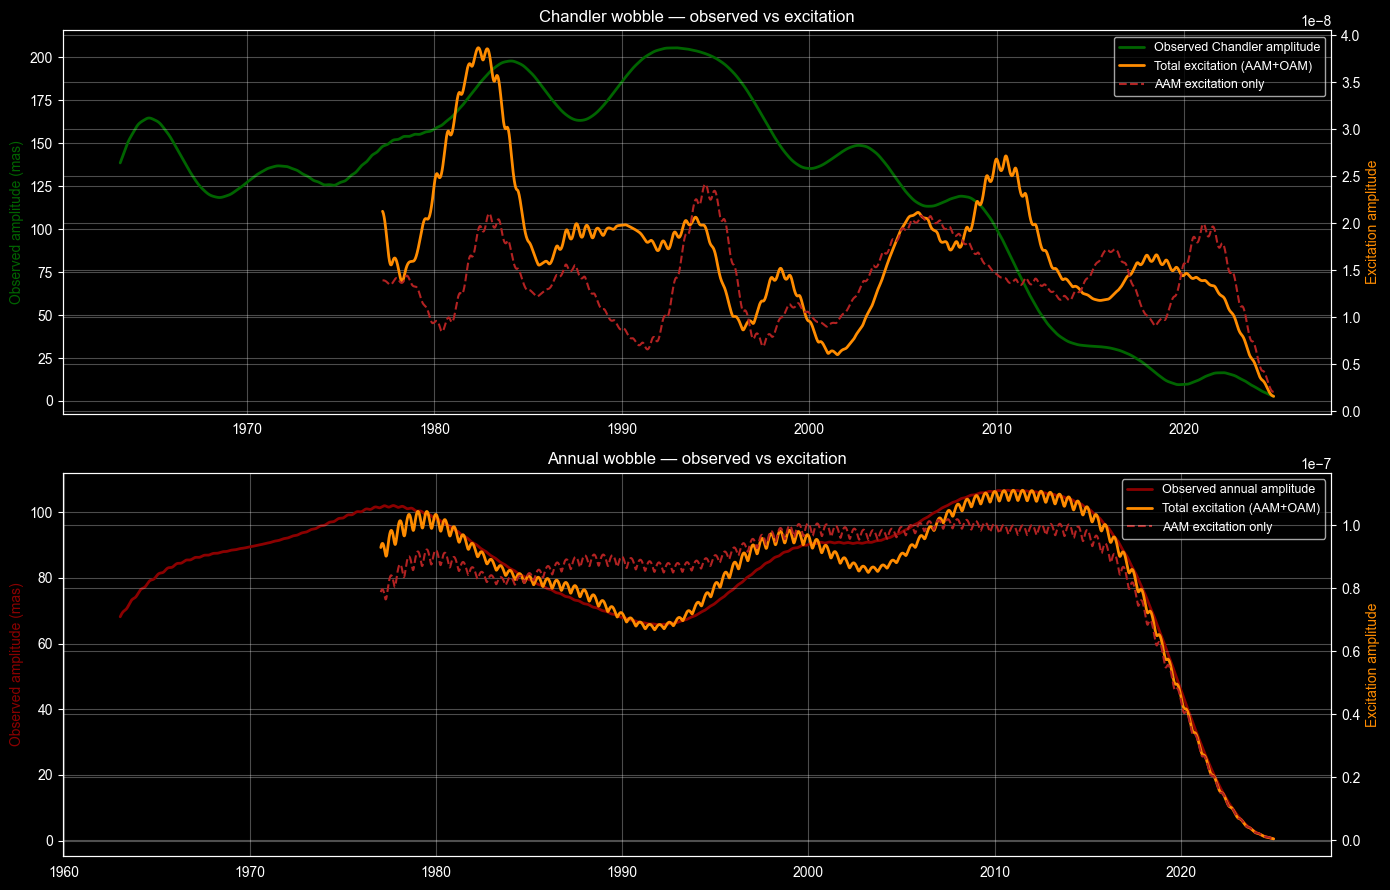

In [11]:
# Smooth envelopes (~2x period for stable envelope)
sm = 900  # Chandler smoothing window
sm_a = 750  # Annual smoothing window

obs_cw_smooth = pd.Series(obs_chandler_amp, index=pm_idx).rolling(sm, center=True).mean()
obs_aw_smooth = pd.Series(obs_annual_amp, index=pm_idx).rolling(sm_a, center=True).mean()

exc_cw_smooth = pd.Series(exc_chandler_amp, index=exc_dates).rolling(sm, center=True).mean()
exc_aw_smooth = pd.Series(exc_annual_amp, index=exc_dates).rolling(sm_a, center=True).mean()

exc_aam_cw_smooth = pd.Series(exc_aam_chandler_amp, index=exc_dates).rolling(sm, center=True).mean()
exc_aam_aw_smooth = pd.Series(exc_aam_annual_amp, index=exc_dates).rolling(sm_a, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Chandler
ax = axes[0]
ax.plot(obs_cw_smooth.index, obs_cw_smooth, lw=2, color='darkgreen', label='Observed Chandler amplitude')
ax2 = ax.twinx()
ax2.plot(exc_cw_smooth.index, exc_cw_smooth, lw=2, color='darkorange', label='Total excitation (AAM+OAM)')
ax2.plot(exc_aam_cw_smooth.index, exc_aam_cw_smooth, lw=1.5, ls='--', color='firebrick', label='AAM excitation only')
ax.set_ylabel('Observed amplitude (mas)', color='darkgreen')
ax2.set_ylabel('Excitation amplitude', color='darkorange')
ax.set_title('Chandler wobble — observed vs excitation')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

# Annual
ax = axes[1]
ax.plot(obs_aw_smooth.index, obs_aw_smooth, lw=2, color='darkred', label='Observed annual amplitude')
ax3 = ax.twinx()
ax3.plot(exc_aw_smooth.index, exc_aw_smooth, lw=2, color='darkorange', label='Total excitation (AAM+OAM)')
ax3.plot(exc_aam_aw_smooth.index, exc_aam_aw_smooth, lw=1.5, ls='--', color='firebrick', label='AAM excitation only')
ax.set_ylabel('Observed amplitude (mas)', color='darkred')
ax3.set_ylabel('Excitation amplitude', color='darkorange')
ax.set_title('Annual wobble — observed vs excitation')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Excitation amplitude trend — is forcing weakening?

Compare the decline rates of observed wobble and excitation amplitude since 2000.

In [12]:
from numpy.polynomial import polynomial as P

def fit_trend(series, start='2000-01-01'):
    """Fit linear trend to series from start date. Returns slope per year, intercept, fitted."""
    s = series.loc[start:].dropna()
    if len(s) < 365:
        return np.nan, np.nan, None
    t = (s.index - s.index[0]).days.values.astype(float)
    coef = P.polyfit(t, s.values, 1)
    slope_per_year = coef[1] * 365.25
    fitted = P.polyval(t, coef)
    pct_change = (fitted[-1] - fitted[0]) / fitted[0] * 100
    return slope_per_year, pct_change, pd.Series(fitted, index=s.index)

results = {}
for name, series in [
    ('Observed Chandler', obs_cw_smooth),
    ('Excitation Chandler (AAM+OAM)', exc_cw_smooth),
    ('Excitation Chandler (AAM only)', exc_aam_cw_smooth),
    ('Observed Annual', obs_aw_smooth),
    ('Excitation Annual (AAM+OAM)', exc_aw_smooth),
    ('Excitation Annual (AAM only)', exc_aam_aw_smooth),
]:
    slope, pct, fitted = fit_trend(series)
    results[name] = (slope, pct)

print(f"{'Component':<40} {'Trend (/yr)':>15} {'Total change':>15}")
print('-' * 73)
for name, (slope, pct) in results.items():
    print(f"{name:<40} {slope:>15.4e} {pct:>14.1f}%")

Component                                    Trend (/yr)    Total change
-------------------------------------------------------------------------
Observed Chandler                            -6.9961e+00         -111.0%
Excitation Chandler (AAM+OAM)                -1.5073e-10          -22.5%
Excitation Chandler (AAM only)               -1.2930e-10          -20.2%
Observed Annual                              -3.4527e+00          -70.8%
Excitation Annual (AAM+OAM)                  -3.3783e-09          -69.5%
Excitation Annual (AAM only)                 -3.7751e-09          -75.5%


## 6. Spectral coherence — forcing vs response

Magnitude-squared coherence between excitation and observed polar motion.
High coherence at Chandler/annual periods means the wobble is well-explained by the forcing.
Declining coherence would suggest the transfer function (Earth's response) is changing.

/var/folders/l_/gygrhglj1vvc7rfw922_nb440000gn/T/ipykernel_67752/113316009.py:34: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/l_/gygrhglj1vvc7rfw922_nb440000gn/T/ipykernel_67752/113316009.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/tedslusser/PycharmProjects/ecdo-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tedslusser/PycharmProjects/ecdo-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


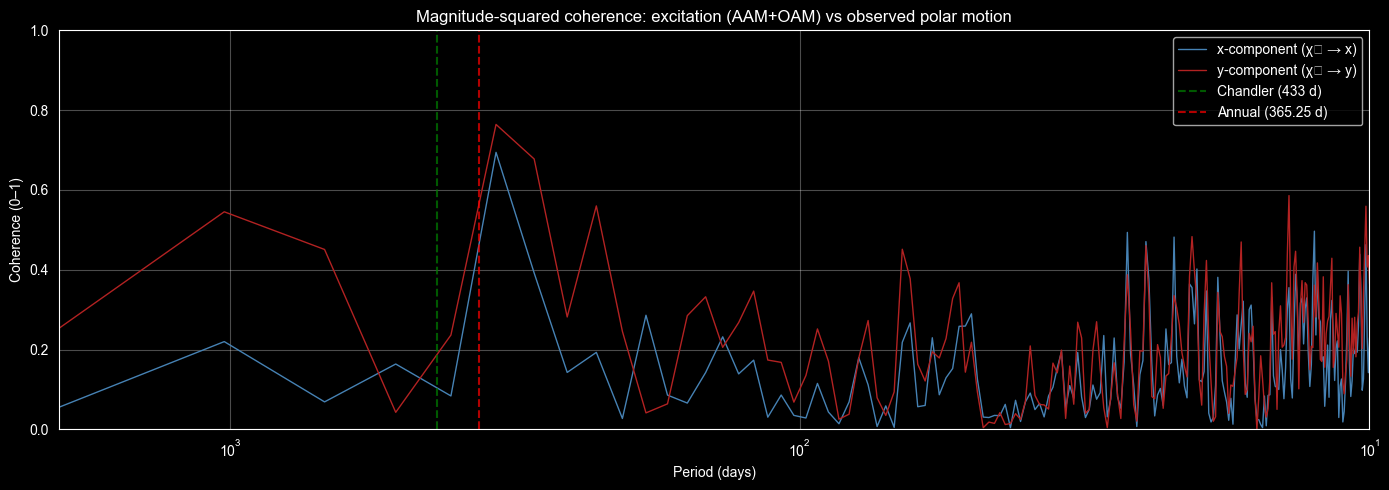

In [13]:
# Align observed and excitation on common dates
common_dates = pm_idx.intersection(exc_dates)

# Get indices into the respective arrays
obs_mask = pm_idx.isin(common_dates)
exc_mask = exc_dates.isin(common_dates)

x_obs = x_det[obs_mask]
y_obs = y_det[obs_mask]
chi1_exc = chi1_v[exc_mask]
chi2_exc = chi2_v[exc_mask]

nperseg = 2048

# Coherence: x_obs vs chi1 (both are "towards Greenwich" component)
f_coh, coh_x = signal.coherence(x_obs, chi1_exc, fs=1.0, nperseg=nperseg)
_, coh_y = signal.coherence(y_obs, chi2_exc, fs=1.0, nperseg=nperseg)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(1/f_coh[1:], coh_x[1:], lw=1, color='steelblue', label='x-component (χ₁ → x)')
ax.plot(1/f_coh[1:], coh_y[1:], lw=1, color='firebrick', label='y-component (χ₂ → y)')

ax.axvline(433, ls='--', color='green', alpha=0.7, label='Chandler (433 d)')
ax.axvline(365.25, ls='--', color='red', alpha=0.7, label='Annual (365.25 d)')

ax.set_xlabel('Period (days)')
ax.set_ylabel('Coherence (0–1)')
ax.set_title('Magnitude-squared coherence: excitation (AAM+OAM) vs observed polar motion')
ax.set_xlim(10, 2000)
ax.set_xscale('log')
ax.set_ylim(0, 1)
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 7. Time-varying coherence — is the coupling changing?

Compute coherence in sliding 10-year windows to check if the
forcing–response relationship is stable over time.

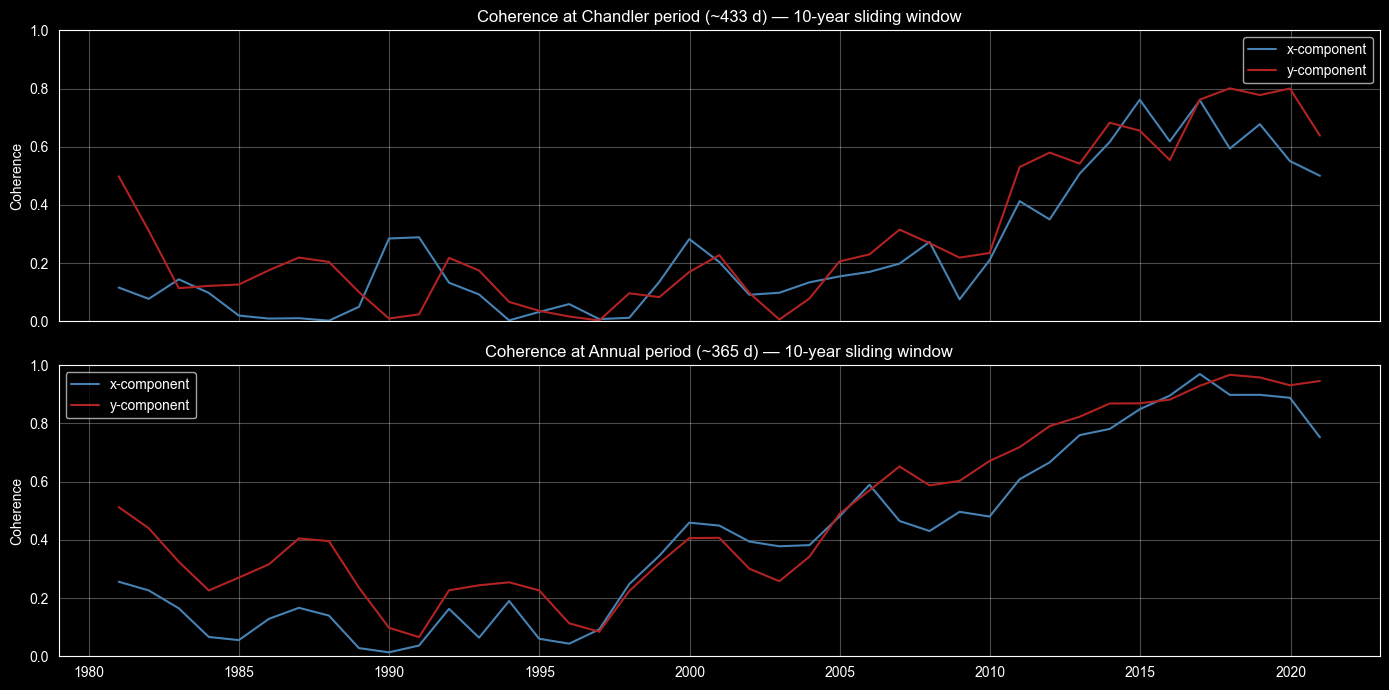

In [14]:
# Sliding window coherence at Chandler and annual frequencies
window_years = 10
window_days = int(window_years * 365.25)
step_days = 365  # 1-year step

def windowed_coherence_at_period(x, y, fs, target_period, window, step, nperseg=1024):
    """Compute coherence at a target period in sliding windows."""
    n = len(x)
    centers = []
    coh_vals = []
    for start in range(0, n - window, step):
        end = start + window
        f, coh = signal.coherence(x[start:end], y[start:end], fs=fs, nperseg=min(nperseg, window//3))
        # Find frequency closest to target period
        target_freq = 1.0 / target_period
        idx = np.argmin(np.abs(f - target_freq))
        coh_vals.append(coh[idx])
        centers.append(start + window // 2)
    return np.array(centers), np.array(coh_vals)

# Chandler coherence over time
c_centers, c_coh_x = windowed_coherence_at_period(x_obs, chi1_exc, 1.0, 433, window_days, step_days)
_, c_coh_y = windowed_coherence_at_period(y_obs, chi2_exc, 1.0, 433, window_days, step_days)

# Annual coherence over time
a_centers, a_coh_x = windowed_coherence_at_period(x_obs, chi1_exc, 1.0, 365.25, window_days, step_days)
_, a_coh_y = windowed_coherence_at_period(y_obs, chi2_exc, 1.0, 365.25, window_days, step_days)

# Convert center indices to dates
c_dates = common_dates[c_centers]
a_dates = common_dates[a_centers]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(c_dates, c_coh_x, lw=1.5, color='steelblue', label='x-component')
axes[0].plot(c_dates, c_coh_y, lw=1.5, color='firebrick', label='y-component')
axes[0].set_ylabel('Coherence')
axes[0].set_ylim(0, 1)
axes[0].set_title(f'Coherence at Chandler period (~433 d) — {window_years}-year sliding window')
axes[0].legend()

axes[1].plot(a_dates, a_coh_x, lw=1.5, color='steelblue', label='x-component')
axes[1].plot(a_dates, a_coh_y, lw=1.5, color='firebrick', label='y-component')
axes[1].set_ylabel('Coherence')
axes[1].set_ylim(0, 1)
axes[1].set_title(f'Coherence at Annual period (~365 d) — {window_years}-year sliding window')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Liouville equation — predict polar motion from forcing

The linearized Liouville equation in the frequency domain:

$$\hat{m}(\sigma) = \frac{\sigma_c}{\sigma - \sigma_c} \hat{\chi}(\sigma)$$

where $m = x - iy$ (complex polar motion), $\chi = \chi_1 + i\chi_2$ (excitation),
and $\sigma_c = \frac{2\pi}{T_c}(1 + \frac{i}{2Q})$ is the complex Chandler frequency.

This acts as a resonance filter — excitation near the Chandler frequency is amplified by a factor ~Q.

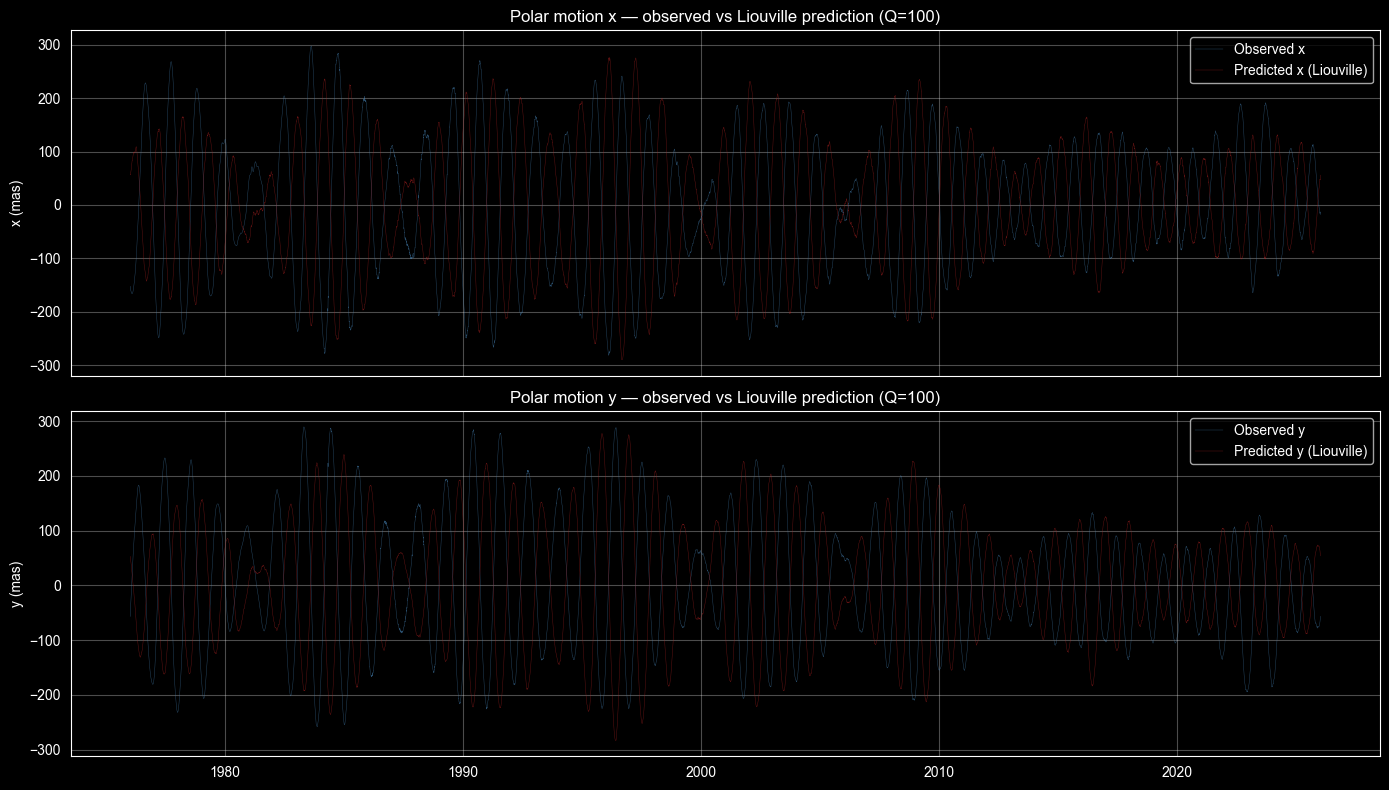

In [15]:
# Liouville transfer function
T_chandler = 433.0  # days
Q_chandler = 100     # quality factor (typical estimate, range 30-200)

# Complex Chandler frequency (radians/day)
sigma_c = (2 * np.pi / T_chandler) * (1 + 1j / (2 * Q_chandler))

# Complex excitation in the overlap window
chi_complex = chi1_exc + 1j * chi2_exc

# FFT-based convolution via Liouville transfer function
N = len(chi_complex)
freqs_fft = np.fft.fftfreq(N, d=1.0)  # cycles/day
sigma_fft = 2 * np.pi * freqs_fft       # rad/day

# Transfer function H(σ) = σ_c / (σ - σ_c)
H = sigma_c / (sigma_fft - sigma_c)
H[0] = 0  # zero DC

# Predicted polar motion
chi_fft = np.fft.fft(chi_complex)
m_predicted = np.fft.ifft(H * chi_fft)

# Convert to mas (excitation is dimensionless radians, need to scale)
# The ESMGFZ excitation functions are in radians; 1 rad = 206265 arcsec = 206265000 mas
rad_to_mas = 206265.0 * 1000
m_pred_mas = m_predicted * rad_to_mas

m_obs = x_obs - 1j * y_obs  # complex observed polar motion in mas

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(common_dates, np.real(m_obs), lw=0.3, alpha=0.6, color='steelblue', label='Observed x')
axes[0].plot(common_dates, np.real(m_pred_mas), lw=0.3, alpha=0.6, color='firebrick', label='Predicted x (Liouville)')
axes[0].set_ylabel('x (mas)')
axes[0].set_title(f'Polar motion x — observed vs Liouville prediction (Q={Q_chandler})')
axes[0].legend()

axes[1].plot(common_dates, -np.imag(m_obs), lw=0.3, alpha=0.6, color='steelblue', label='Observed y')
axes[1].plot(common_dates, -np.imag(m_pred_mas), lw=0.3, alpha=0.6, color='firebrick', label='Predicted y (Liouville)')
axes[1].set_ylabel('y (mas)')
axes[1].set_title(f'Polar motion y — observed vs Liouville prediction (Q={Q_chandler})')
axes[1].legend()

plt.tight_layout()
plt.show()

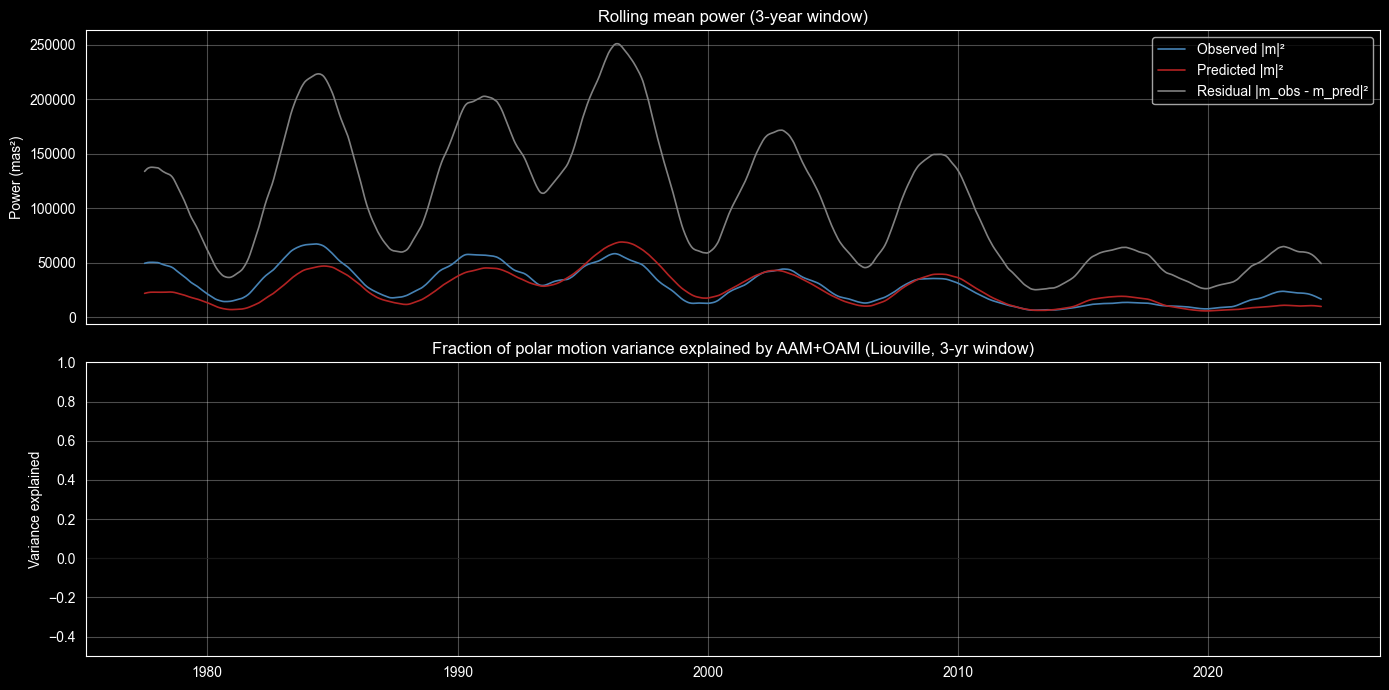

In [21]:
# Residual variance over time — is the model getting worse or better?
residual_complex = m_obs - m_pred_mas

window_rv = 3 * 365
rv_obs = pd.Series(np.abs(m_obs)**2, index=common_dates).rolling(window_rv, center=True).mean()
rv_pred = pd.Series(np.abs(m_pred_mas)**2, index=common_dates).rolling(window_rv, center=True).mean()
rv_resid = pd.Series(np.abs(residual_complex)**2, index=common_dates).rolling(window_rv, center=True).mean()

# Variance explained ratio
var_explained = 1 - rv_resid / rv_obs

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(rv_obs.index, rv_obs, lw=1.2, color='steelblue', label='Observed |m|²')
axes[0].plot(rv_pred.index, rv_pred, lw=1.2, color='firebrick', label='Predicted |m|²')
axes[0].plot(rv_resid.index, rv_resid, lw=1.2, color='gray', label='Residual |m_obs - m_pred|²')
axes[0].set_ylabel('Power (mas²)')
axes[0].set_title('Rolling mean power (3-year window)')
axes[0].legend()

axes[1].plot(var_explained.index, var_explained, lw=1.5, color='darkgreen')
axes[1].axhline(0, ls='-', color='black', lw=0.5)
axes[1].set_ylabel('Variance explained')
axes[1].set_title('Fraction of polar motion variance explained by AAM+OAM (Liouville, 3-yr window)')
axes[1].set_ylim(-0.5, 1.0)

plt.tight_layout()
plt.show()

## 9. Summary: excitation decline vs wobble decline

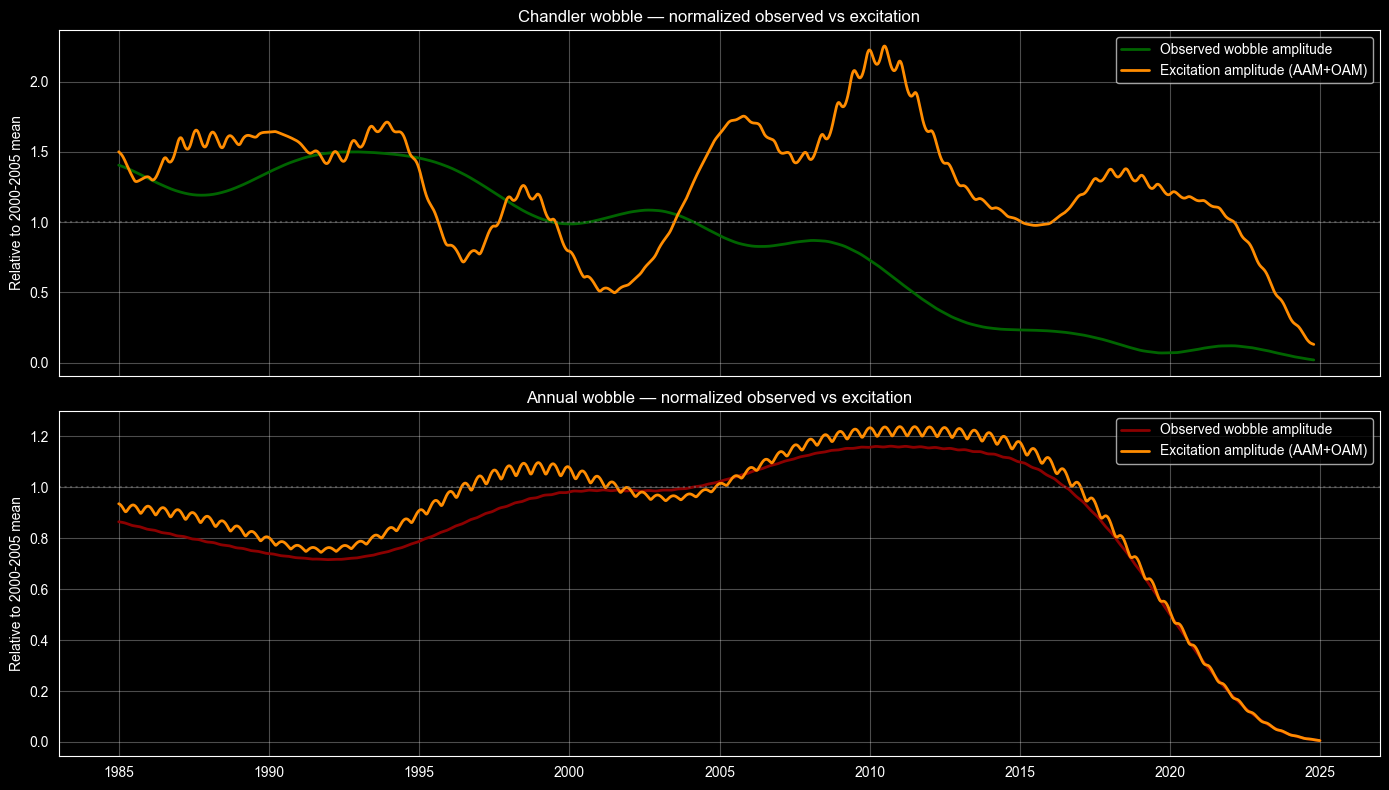

If the orange and green/red curves track each other → excitation is driving the decline.
If they diverge (wobble drops faster than excitation) → dissipation is increasing.
If excitation is flat but wobble drops → the forcing is being absorbed differently.


In [17]:
# Normalize both to their 2000-2005 mean for direct comparison
def normalize_to_baseline(series, baseline_start='2000-01-01', baseline_end='2005-12-31'):
    baseline = series.loc[baseline_start:baseline_end].mean()
    return series / baseline

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Chandler
ax = axes[0]
s1 = normalize_to_baseline(obs_cw_smooth).loc['1985':]
s2 = normalize_to_baseline(exc_cw_smooth).loc['1985':]
ax.plot(s1.index, s1, lw=2, color='darkgreen', label='Observed wobble amplitude')
ax.plot(s2.index, s2, lw=2, color='darkorange', label='Excitation amplitude (AAM+OAM)')
ax.axhline(1.0, ls=':', color='gray', alpha=0.5)
ax.set_ylabel('Relative to 2000-2005 mean')
ax.set_title('Chandler wobble — normalized observed vs excitation')
ax.legend(fontsize=10)

# Annual
ax = axes[1]
s3 = normalize_to_baseline(obs_aw_smooth).loc['1985':]
s4 = normalize_to_baseline(exc_aw_smooth).loc['1985':]
ax.plot(s3.index, s3, lw=2, color='darkred', label='Observed wobble amplitude')
ax.plot(s4.index, s4, lw=2, color='darkorange', label='Excitation amplitude (AAM+OAM)')
ax.axhline(1.0, ls=':', color='gray', alpha=0.5)
ax.set_ylabel('Relative to 2000-2005 mean')
ax.set_title('Annual wobble — normalized observed vs excitation')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("If the orange and green/red curves track each other → excitation is driving the decline.")
print("If they diverge (wobble drops faster than excitation) → dissipation is increasing.")
print("If excitation is flat but wobble drops → the forcing is being absorbed differently.")

## 10. Phase analysis — is the push going out of sync?

For the Chandler wobble (a resonance), **when** you push matters as much as **how hard**.
Using the complex representation of bandpassed wobble and excitation, we can track
the instantaneous phase difference over time.

- **Stable phase** → consistent energy transfer (constructive or destructive)
- **Drifting phase** → the forcing is shifting in/out of sync with the natural wobble
- **Phase near 0°** → excitation aligned with wobble displacement (maintaining amplitude)
- **Phase near ±180°** → excitation opposing wobble (actively damping it)

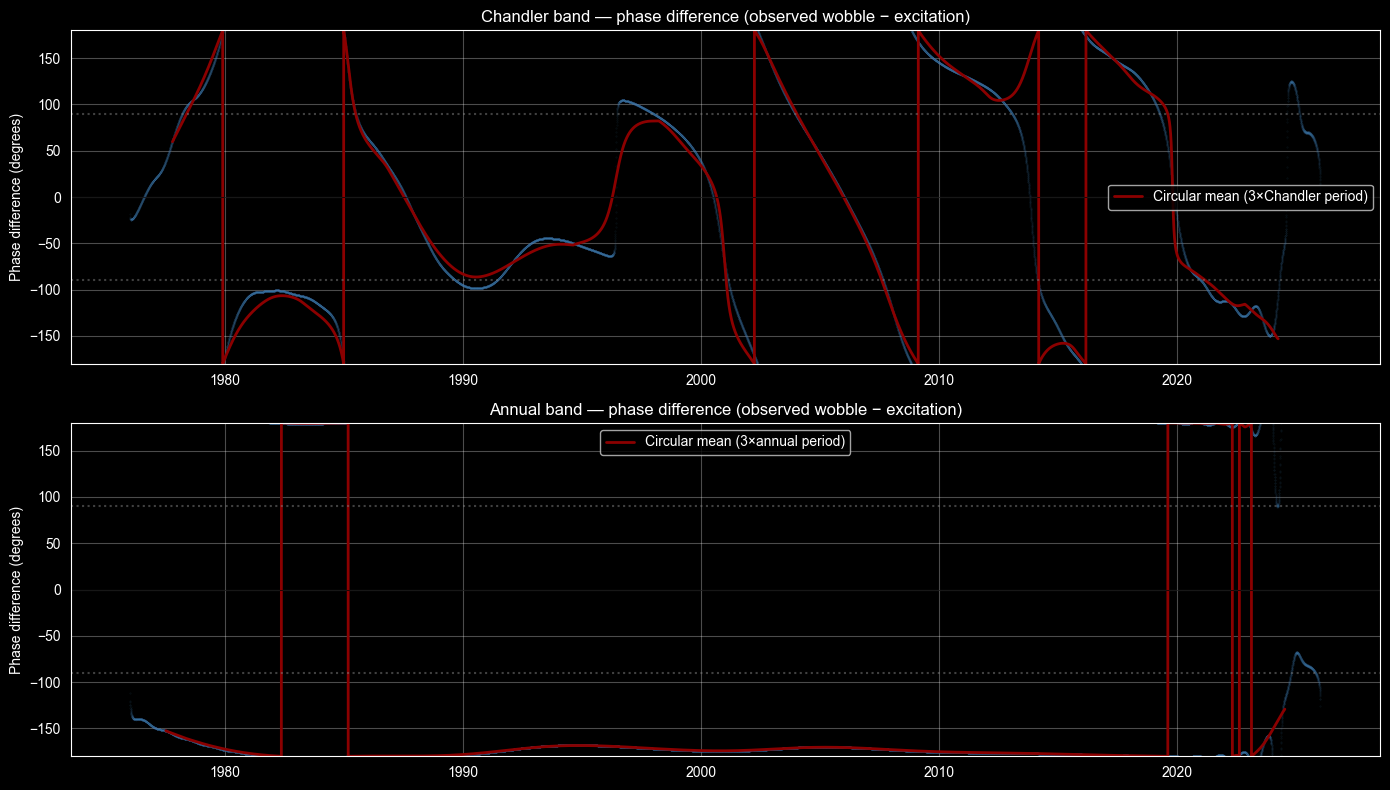

In [19]:
# Complex bandpassed signals
# Observed wobble in Chandler band
m_cw_obs = x_cw - 1j * y_cw   # complex polar motion (Chandler band) — on pm_idx
# Excitation in Chandler band
chi_cw_exc = chi1_cw + 1j * chi2_cw  # complex excitation (Chandler band) — on exc_dates

# Use Hilbert transform for clean instantaneous phase
from scipy.signal import hilbert

# Observed: analytic signal from x and y components
analytic_obs_x = hilbert(x_cw)
analytic_obs_y = hilbert(y_cw)
phase_obs = np.angle(analytic_obs_x - 1j * analytic_obs_y)  # instantaneous phase of wobble

# Excitation: analytic signal
analytic_exc_1 = hilbert(chi1_cw)
analytic_exc_2 = hilbert(chi2_cw)
phase_exc = np.angle(analytic_exc_1 + 1j * analytic_exc_2)  # instantaneous phase of excitation

# Phase difference on the overlap window
# Align indices
obs_on_exc = pm_idx.isin(exc_dates)
exc_on_obs = exc_dates.isin(pm_idx)

phase_obs_aligned = phase_obs[obs_on_exc]
phase_exc_aligned = phase_exc[exc_on_obs]
phase_dates = pm_idx[obs_on_exc]

# Phase difference (wrapped to [-π, π])
phase_diff = np.angle(np.exp(1j * (phase_obs_aligned - phase_exc_aligned)))

# Smooth with ~3 Chandler periods for trend visibility
phase_diff_smooth = pd.Series(phase_diff, index=phase_dates).rolling(
    3 * 433, center=True).apply(
    lambda x: np.angle(np.mean(np.exp(1j * x))),  # circular mean
    raw=True
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Raw + smoothed phase difference
axes[0].scatter(phase_dates, np.degrees(phase_diff), s=0.1, alpha=0.15, color='steelblue')
axes[0].plot(phase_diff_smooth.index, np.degrees(phase_diff_smooth), lw=2, color='darkred',
             label='Circular mean (3×Chandler period)')
axes[0].set_ylabel('Phase difference (degrees)')
axes[0].set_ylim(-180, 180)
axes[0].axhline(0, ls='-', color='black', lw=0.5)
axes[0].axhline(90, ls=':', color='gray', alpha=0.5)
axes[0].axhline(-90, ls=':', color='gray', alpha=0.5)
axes[0].set_title('Chandler band — phase difference (observed wobble − excitation)')
axes[0].legend()

# Same for annual band
analytic_obs_x_a = hilbert(x_aw)
analytic_obs_y_a = hilbert(y_aw)
phase_obs_a = np.angle(analytic_obs_x_a - 1j * analytic_obs_y_a)

analytic_exc_1_a = hilbert(chi1_aw)
analytic_exc_2_a = hilbert(chi2_aw)
phase_exc_a = np.angle(analytic_exc_1_a + 1j * analytic_exc_2_a)

phase_obs_a_aligned = phase_obs_a[obs_on_exc]
phase_exc_a_aligned = phase_exc_a[exc_on_obs]

phase_diff_a = np.angle(np.exp(1j * (phase_obs_a_aligned - phase_exc_a_aligned)))
phase_diff_a_smooth = pd.Series(phase_diff_a, index=phase_dates).rolling(
    3 * 365, center=True).apply(
    lambda x: np.angle(np.mean(np.exp(1j * x))), raw=True
)

axes[1].scatter(phase_dates, np.degrees(phase_diff_a), s=0.1, alpha=0.15, color='steelblue')
axes[1].plot(phase_diff_a_smooth.index, np.degrees(phase_diff_a_smooth), lw=2, color='darkred',
             label='Circular mean (3×annual period)')
axes[1].set_ylabel('Phase difference (degrees)')
axes[1].set_ylim(-180, 180)
axes[1].axhline(0, ls='-', color='black', lw=0.5)
axes[1].axhline(90, ls=':', color='gray', alpha=0.5)
axes[1].axhline(-90, ls=':', color='gray', alpha=0.5)
axes[1].set_title('Annual band — phase difference (observed wobble − excitation)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Effective power input — combining amplitude and phase

The *effective* forcing is not just how hard you push, but how well-timed
the push is. We can compute:

$$P_{\text{eff}} = |\chi| \cdot \cos(\Delta\phi)$$

where $|\chi|$ is the excitation amplitude and $\Delta\phi$ is the phase offset.

- $\cos(\Delta\phi) \approx +1$ → constructive (pushing with the swing)
- $\cos(\Delta\phi) \approx 0$ → wasted effort (pushing sideways)
- $\cos(\Delta\phi) \approx -1$ → destructive (pushing against the swing)

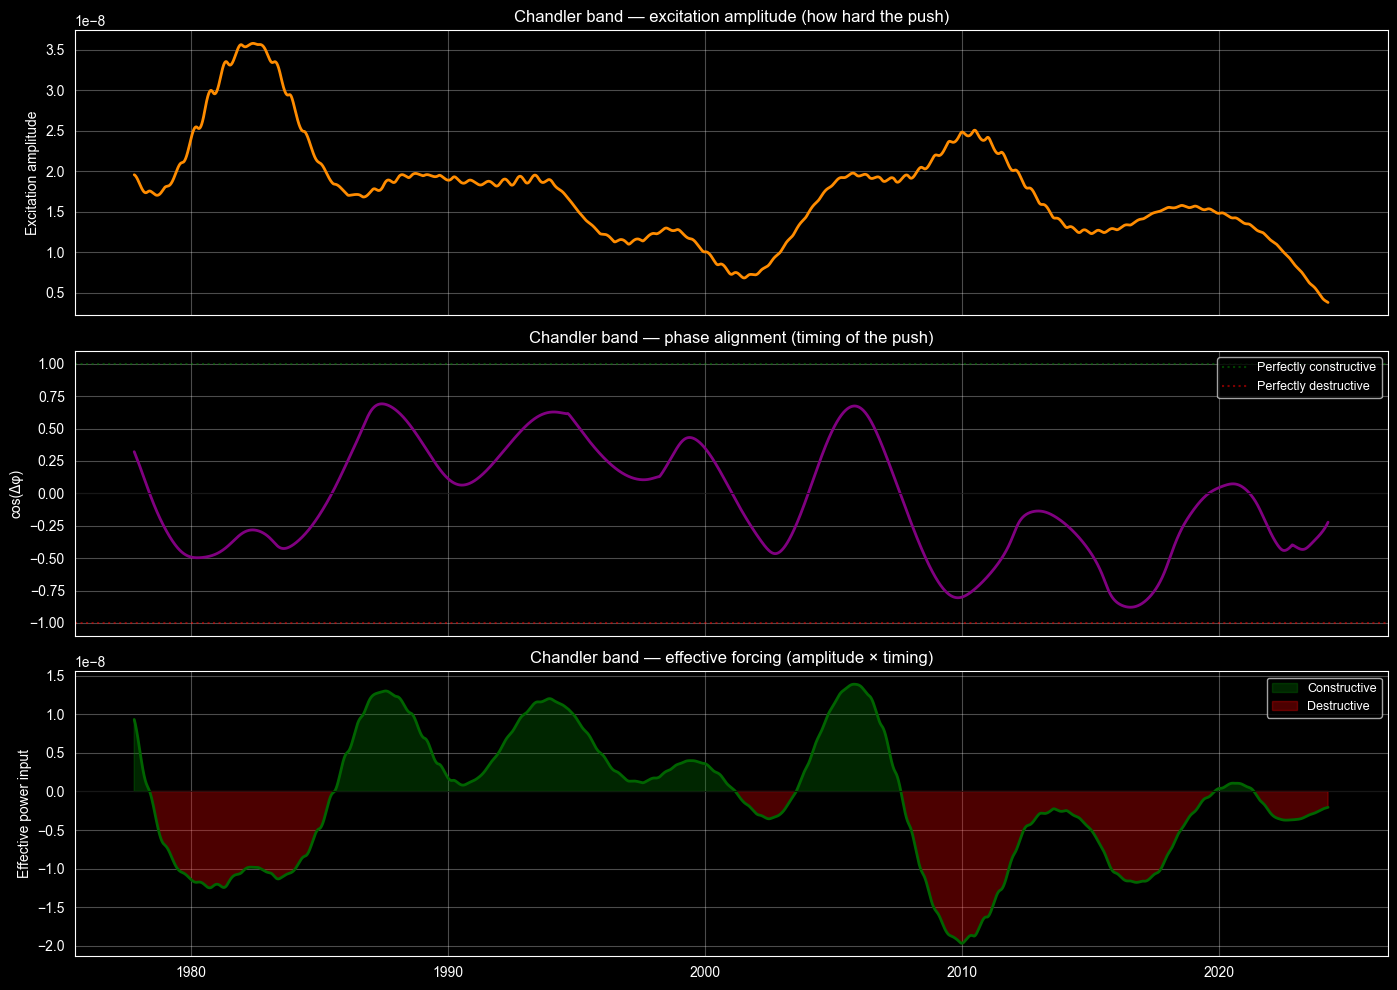

Green = energy flowing INTO the wobble (sustaining it)
Red = energy flowing OUT of the wobble (damping it)


In [20]:
# Effective power input for Chandler band
exc_amp_aligned = exc_chandler_amp[exc_on_obs]
cos_phase = np.cos(phase_diff)
effective_power = exc_amp_aligned * cos_phase

# Smooth everything on the same window
sm_eff = 3 * 433
eff_smooth = pd.Series(effective_power, index=phase_dates).rolling(sm_eff, center=True).mean()
amp_smooth = pd.Series(exc_amp_aligned, index=phase_dates).rolling(sm_eff, center=True).mean()
cos_smooth = pd.Series(cos_phase, index=phase_dates).rolling(sm_eff, center=True).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Excitation amplitude
axes[0].plot(amp_smooth.index, amp_smooth, lw=2, color='darkorange')
axes[0].set_ylabel('Excitation amplitude')
axes[0].set_title('Chandler band — excitation amplitude (how hard the push)')

# Phase alignment factor
axes[1].plot(cos_smooth.index, cos_smooth, lw=2, color='purple')
axes[1].axhline(0, ls='-', color='black', lw=0.5)
axes[1].axhline(1, ls=':', color='green', alpha=0.5, label='Perfectly constructive')
axes[1].axhline(-1, ls=':', color='red', alpha=0.5, label='Perfectly destructive')
axes[1].set_ylabel('cos(Δφ)')
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title('Chandler band — phase alignment (timing of the push)')
axes[1].legend(fontsize=9)

# Effective power = amplitude × cos(phase)
axes[2].plot(eff_smooth.index, eff_smooth, lw=2, color='darkgreen')
axes[2].axhline(0, ls='-', color='black', lw=0.5)
axes[2].fill_between(eff_smooth.index, 0, eff_smooth,
                      where=eff_smooth > 0, alpha=0.3, color='green', label='Constructive')
axes[2].fill_between(eff_smooth.index, 0, eff_smooth,
                      where=eff_smooth < 0, alpha=0.3, color='red', label='Destructive')
axes[2].set_ylabel('Effective power input')
axes[2].set_title('Chandler band — effective forcing (amplitude × timing)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Green = energy flowing INTO the wobble (sustaining it)")
print("Red = energy flowing OUT of the wobble (damping it)")

---
*Next steps: Decompose excitation into mass vs motion terms,
explore role of ice mass loss (Greenland/Antarctica) in shifting
the excitation pattern, investigate whether hydrological angular
momentum (HAM) data could close the budget.*

In [ ]:
# Excitation budget: what fraction of observed wobble variance is explained?
# Use the Chandler-band and annual-band amplitudes

# Align everything to common dates
budget_idx = pm_idx.intersection(exc_dates)
obs_on_b = pm_idx.isin(budget_idx)
exc_on_b = exc_dates.isin(budget_idx)

# Observed wobble variance by band
obs_cw_var = np.var(obs_chandler_amp[obs_on_b])
obs_aw_var = np.var(obs_annual_amp[obs_on_b])

# Excitation variance by band and source
exc_cw_var = np.var(exc_chandler_amp[exc_on_b])
exc_aam_cw_var = np.var(exc_aam_chandler_amp[exc_on_b])
exc_oam_cw_var = exc_cw_var - exc_aam_cw_var  # approximate OAM contribution

exc_aw_var = np.var(exc_annual_amp[exc_on_b])
exc_aam_aw_var = np.var(exc_aam_annual_amp[exc_on_b])
exc_oam_aw_var = exc_aw_var - exc_aam_aw_var

# Also compute by decade
print("=" * 75)
print("EXCITATION BUDGET — Variance explained by AAM+OAM")
print("=" * 75)

# Use the Liouville residual for the real budget
# m_predicted vs m_obs from section 8
from scipy.stats import pearsonr

# Overall correlation
r_x = pearsonr(np.real(m_obs), np.real(m_pred_mas))[0]
r_y = pearsonr(-np.imag(m_obs), -np.imag(m_pred_mas))[0]

# Variance explained (R²)
total_obs_var = np.var(np.abs(m_obs))
total_pred_var = np.var(np.abs(m_pred_mas))
total_resid_var = np.var(np.abs(m_obs - m_pred_mas))

print(f"\nOverall (Liouville prediction, full record):")
print(f"  Correlation x-component: {r_x:.3f}")
print(f"  Correlation y-component: {r_y:.3f}")
print(f"  Observed |m| variance:   {total_obs_var:.2f} mas²")
print(f"  Predicted |m| variance:  {total_pred_var:.2f} mas²")
print(f"  Residual |m| variance:   {total_resid_var:.2f} mas²")
print(f"  Variance explained:      {(1 - total_resid_var/total_obs_var)*100:.1f}%")
print(f"  UNACCOUNTED:             {(total_resid_var/total_obs_var)*100:.1f}%")

# By decade
print(f"\n{'Decade':<12} {'Var explained':>15} {'Unaccounted':>15}")
print("-" * 45)
for start_yr in range(1980, 2030, 10):
    end_yr = start_yr + 10
    mask = (common_dates >= f'{start_yr}-01-01') & (common_dates < f'{end_yr}-01-01')
    if mask.sum() > 365:
        obs_dec = m_obs[mask]
        pred_dec = m_pred_mas[mask]
        resid_dec = obs_dec - pred_dec
        v_obs = np.var(np.abs(obs_dec))
        v_resid = np.var(np.abs(resid_dec))
        ve = (1 - v_resid / v_obs) * 100
        print(f"{start_yr}-{end_yr:<7} {ve:>14.1f}% {100-ve:>14.1f}%")